In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

os.chdir(r'c:\Repositories\asphalt-db')
#swithc working directory to 
from src.db_builder.models import *
sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')

In [2]:
#load csv with new data
df_new = pd.read_csv(working_dir.joinpath("Dikes_Projects_Samples_Tests_2.csv"))

#load excel with old data
df_old = pd.read_excel(r"c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\Database WAB - overzicht ADL28062023_BWich_selection18.8.xlsx")



In [3]:
df_new.head()

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,test_id_vs,sample_name_vs,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat,HR_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,2.0,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490.0,HR 3-6%
1,2,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,5.0,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000.0,HR 3-6%
2,3,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,8.0,K3-b2b,13.6,13.1,2.781395,0.116814,2302.0,2157.0,2000.0,HR 3-6%
3,4,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,11.0,K4-b2,10.7,9.0,1.687917,0.116208,1859.0,2615.0,29000.0,HR 3-6%
4,5,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,14.0,K5-b2b,12.6,11.5,2.282727,0.114500,2389.0,2209.0,2500.0,HR 3-6%


In [4]:
df_old.head()

,Project\nnr.,Dijkring,Dijktraject,Dijknaam,Kilometrering\nboring,Waterschap / beheerder,Projectnummer,Totaal aantal kernen in project,Totaal aantal \nkernen in \ndijkvak,Boorkern,...,Buigtreksterkte,Type test (3PB/SCB),Verplaatssings\nsnelheid,Temperatuur Buigtreksterkte proef,Vermoeiingsonderzoek?,Vermoeiing α,Vermoeiing β,Visuele Inspectie,Jaar van inspectie,Overig uitgevoerd binnen project
0,3,13,13-4,Helderse zeewering,3300,HHNK,048304,24,8,1,...,6.25,3PB,0.085,5,ja,-,-,nee,-,"elasticiteitsmodulus, beddingsconstante"
1,3,13,13-4,Helderse zeewering,3301,HHNK,048304,24,8,2,...,6.21,3PB,0.085,5,ja,-,-,nee,-,NaN
2,3,13,13-4,Helderse zeewering,3351,HHNK,048304,24,8,3,...,5.43,3PB,0.085,5,ja,-,-,nee,-,NaN
3,3,13,13-4,Helderse zeewering,3353,HHNK,048304,24,8,4,...,5.92,3PB,0.085,5,ja,-,-,nee,-,NaN
4,3,13,13-4,Helderse zeewering,3401,HHNK,048304,24,8,5,...,6.61,3PB,0.085,5,ja,-,-,nee,-,NaN


In [5]:
df_old['Buigtreksterkte'].shape

(661,)

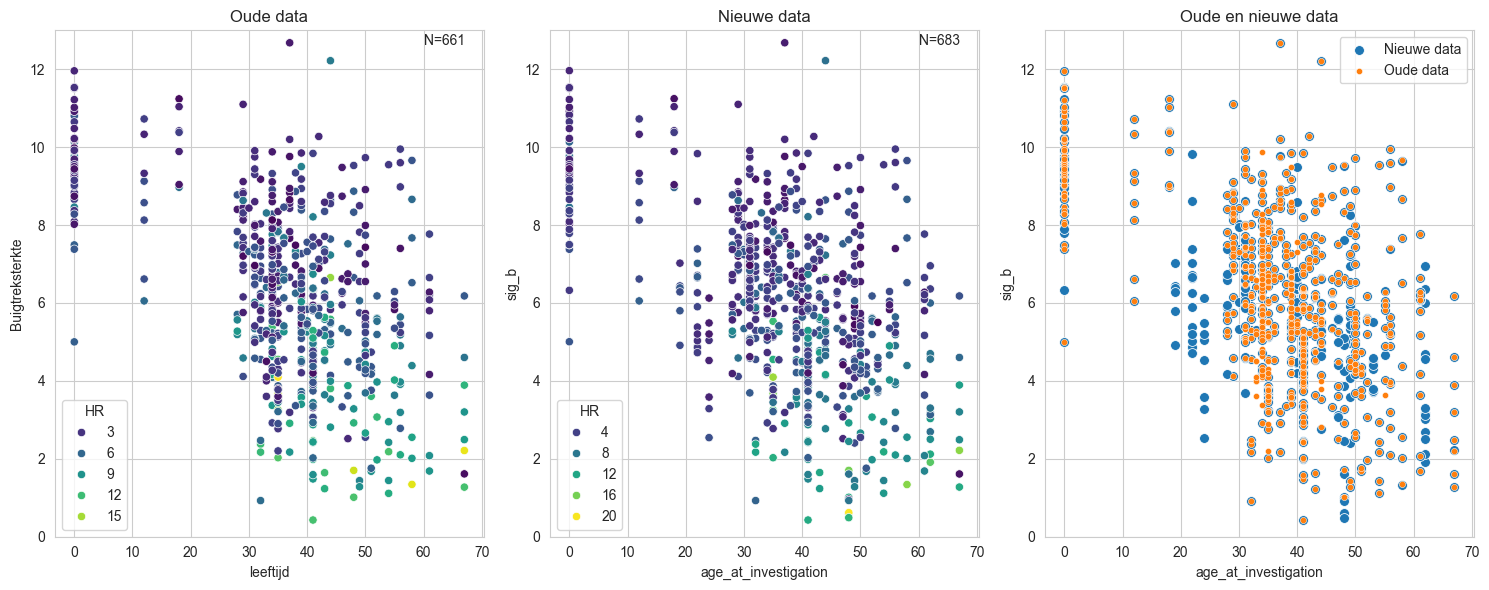

In [6]:
fig,ax = plt.subplots(ncols=3, figsize=(15,6))
sns.scatterplot(data=df_old, x = 'leeftijd', y = 'Buigtreksterkte',hue='HR', ax=ax[0],palette='viridis')
sns.scatterplot(data=df_new, x = 'age_at_investigation', y = 'sig_b', hue='HR', ax=ax[1],palette='viridis')
sns.scatterplot(data=df_new, x = 'age_at_investigation', y = 'sig_b', ax=ax[2],s=50,label='Nieuwe data')
sns.scatterplot(data=df_old, x = 'leeftijd', y = 'Buigtreksterkte', ax=ax[2],s=20, label='Oude data')
ax[0].set_title('Oude data')
ax[1].set_title('Nieuwe data')
ax[2].set_title('Oude en nieuwe data')

ax[0].set_ylim(0,13)
ax[1].set_ylim(0,13)
ax[2].set_ylim(0,13)
#aantal punten met buigtreksterkte in beide dataframes:
ax[0].text(60, 12.9, f"N={df_old['Buigtreksterkte'].dropna().shape[0]}",verticalalignment='top')
ax[1].text(60, 12.9, f"N={df_new['sig_b'].dropna().shape[0]}",verticalalignment='top')
ax[2].legend()
plt.tight_layout()

<Axes: xlabel='leeftijd', ylabel='Buigtreksterkte'>

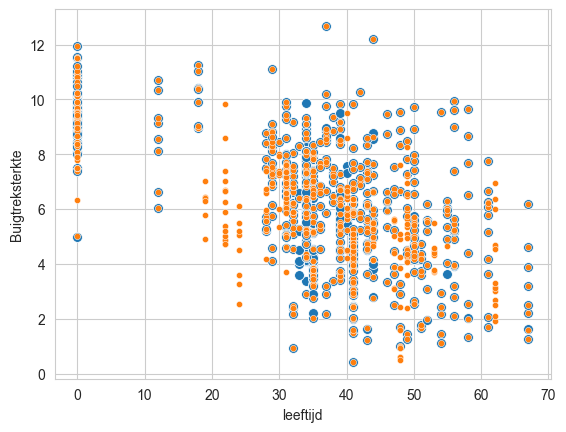

In [19]:
sns.scatterplot(data=df_old, x = 'leeftijd', y = 'Buigtreksterkte',s=50)
sns.scatterplot(data=df_new, x = 'age_at_investigation', y = 'sig_b',s=20)

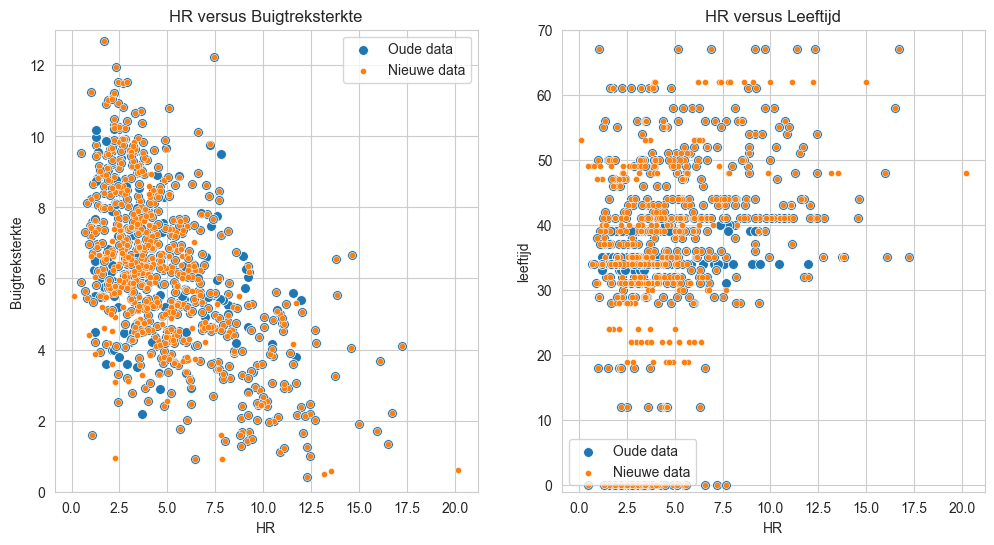

In [43]:
#HR versus buigtreksterkte voor beiden
fig,ax = plt.subplots(ncols = 2,figsize=(12,6))
sns.scatterplot(data=df_old, x = 'HR', y = 'Buigtreksterkte', ax=ax[0],s=50,label='Oude data')
sns.scatterplot(data=df_new, x = 'HR', y = 'sig_b', ax=ax[0],s=20,label='Nieuwe data')
ax[0].set_title('HR versus Buigtreksterkte')    
ax[0].set_ylim(0,13)

sns.scatterplot(data=df_old, x = 'HR', y = 'leeftijd', ax=ax[1],s=50, label='Oude data')
sns.scatterplot(data=df_new, x = 'HR', y = 'age_at_investigation', ax=ax[1],s=20, label='Nieuwe data')
ax[1].set_title('HR versus Leeftijd')
ax[1].set_ylim(-1,70)
ax[1].legend()


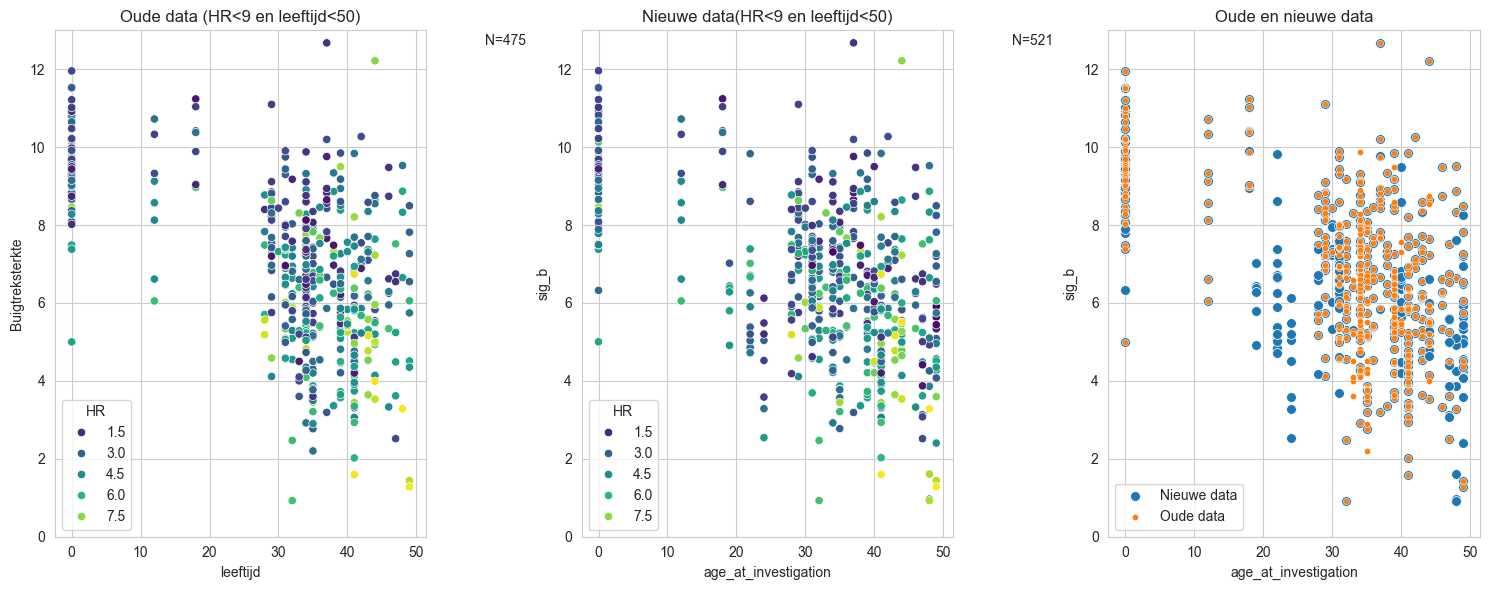

In [42]:
#filter df voor leeftijd <50 en HR <9
df_old_filtered = df_old[df_old['leeftijd']<50]
df_old_filtered = df_old_filtered[df_old_filtered['HR']<9]
df_new_filtered = df_new[df_new['age_at_investigation']<50]
df_new_filtered = df_new_filtered[df_new_filtered['HR']<9]

fig,ax = plt.subplots(ncols=3, figsize=(15,6))
sns.scatterplot(data=df_old_filtered, x = 'leeftijd', y = 'Buigtreksterkte',hue='HR', ax=ax[0],palette='viridis')
sns.scatterplot(data=df_new_filtered, x = 'age_at_investigation', y = 'sig_b', hue='HR', ax=ax[1],palette='viridis')
sns.scatterplot(data=df_new_filtered, x = 'age_at_investigation', y = 'sig_b', ax=ax[2],s=50,label='Nieuwe data')
sns.scatterplot(data=df_old_filtered, x = 'leeftijd', y = 'Buigtreksterkte', ax=ax[2],s=20, label='Oude data')
ax[0].set_title('Oude data (HR<9 en leeftijd<50)')
ax[1].set_title('Nieuwe data(HR<9 en leeftijd<50)')
ax[2].set_title('Oude en nieuwe data')

ax[0].set_ylim(0,13)
ax[1].set_ylim(0,13)
ax[2].set_ylim(0,13)
#aantal punten met buigtreksterkte in beide dataframes:
ax[0].text(60, 12.9, f"N={df_old_filtered['Buigtreksterkte'].shape[0]}",verticalalignment='top')
ax[1].text(60, 12.9, f"N={df_new_filtered['sig_b'].shape[0]}",verticalalignment='top')
ax[2].legend()
plt.tight_layout()

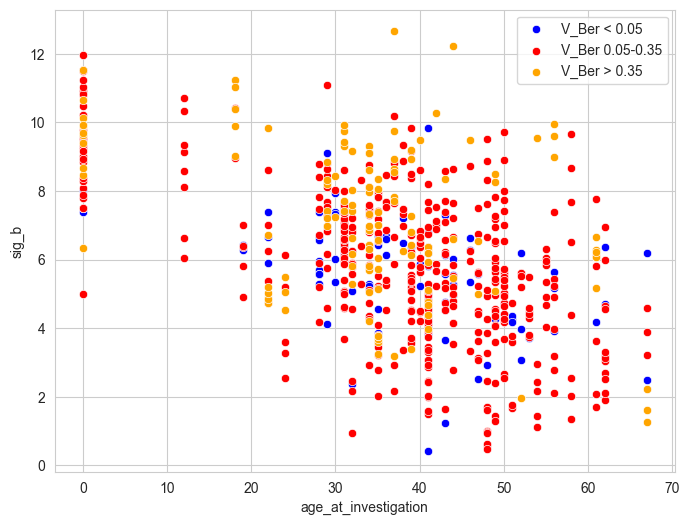

In [77]:
fig,ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_new.loc[df_new['V_Ber']<0.05], x='age_at_investigation', y='sig_b',ax=ax,label='V_Ber < 0.05',color='blue')
sns.scatterplot(data=df_new.loc[(df_new['V_Ber']>=0.05) & (df_new['V_Ber'] <= 0.35)], x='age_at_investigation', y='sig_b',ax=ax,label='V_Ber 0.05-0.35',color='red')
sns.scatterplot(data=df_new.loc[df_new['V_Ber']>0.35], x='age_at_investigation', y='sig_b',ax=ax,label='V_Ber > 0.35',color='orange')
ax.legend()
